# Coding Exercises (Part 2)

Now, you will have the opportunity to practice what you have learned. <br>
__Follow the instructions__ and insert your code! 

The correct answer is provided below your coding cell. There you can check whether your code is correct.

If you need some help or if you want to check your code, you can also have a look at the __solutions__.

### Have Fun!

--------------------------------------------------------------------------------------------------------------

## Exercise 3: Sampling and Estimation

1. Import numpy and the S&P500 price returns (in %) for the year 2018 for the complete population (size = 500). 

In [1]:
# run the cell
import numpy as np
np.set_printoptions(precision=4, suppress= True)
import matplotlib.pyplot as plt
%config InlineBackened.fornat_figure = "svg"

In [2]:
# run the cell
pop = np.loadtxt("SP500_2018.csv", delimiter = ",", usecols = 1)
pop

array([ -1.5081, -38.8238,  55.9434,  -7.6819,  -5.7802, -19.4511,
        69.7722,  24.5663,  -8.6681,  27.3282,  -4.0099,   1.7465,
        10.2739, -40.8947,  21.3679,  10.0865,   1.5767,  31.7636,
         2.4151, -18.8165, -35.1796,  -0.5262, -12.5744,  14.6018,
        -6.1347, -39.9953,  -6.2559, -17.9567, -21.6694,  -1.2695,
       -18.7139, -36.6588, -21.1864,  73.3463,  -7.9205, -53.2229,
         9.678 , -39.1338,  11.3268,  26.3837, -12.6581,  -3.1167,
        15.1415,   7.2388, -30.3198, -37.6125,  -2.06  ,  -8.3485,
       -27.6435, -12.7498, -38.4954,   6.7179, -26.0897,  -3.2173,
        -1.2884, -22.6624,  -1.6067,  -4.924 ,  17.9428,   7.2802,
       -17.378 ,   0.8818, -13.6163, -25.0183,   3.7046, -32.6794,
       -13.6877, -32.2377,  -7.8633, -13.3866,  -1.2608, -24.4262,
        18.362 , -16.8734,   5.0232,   1.9473,  39.8548, -32.4525,
       -13.9199, -30.3454, -43.7749, -27.2401, -20.2881, -12.5368,
       -22.7787,  -7.8966, -26.4237,  -2.6034, -26.6536,   3.6

2. Draw a __random sample__ with sample size __50__ and __save__ the sample. Use the random __seed 123__.

In [3]:
np.random.seed(123)
sample = np.random.choice(pop , size = 50 , replace=False)

++++ __From this point, assume that you only have the sample. You don´t know anything about the population.__++++ 

3. Calculate and save the __sample mean__ (point estimate of the mean).

In [4]:
sample_mean = sample.mean()
sample_mean

-3.8301530353346083

4. Calculate and save the __sample standard deviation__ (point estimate of the std).

In [5]:
sample_std = sample.std(ddof=1)
sample_std

24.56795822088298

5. Calculate the __Standard Error__ of the sample mean.

In [6]:
sample_standard_error = sample_std/np.sqrt(sample.size)
sample_standard_error

3.4744339715788284

6. Estimate the (__equally-weighted__) mean return for the whole S&P 500 population for the year 2018 by constructing a __90% Confidence Interval__.

In [7]:
import scipy.stats as stats

In [8]:
stats.t.interval(confidence=0.90 , 
                 loc = sample_mean , 
                 scale = sample_standard_error , 
                 df = sample.size - 1)

(-9.655218409282309, 1.9949123386130907)

7. __Same as Q6__. This time, construct the 90% Confidence Interval with __Bootstrapping__. Use __100,000 simulations__ and the random __seed 123__.

In [27]:
np.random.seed(123)

bootstrap = []

for i in range(10**5):
    bootstrap.append(np.random.choice(sample , size=sample.size , replace=True).mean())

In [28]:
len(bootstrap)

100000

In [29]:
np.mean(bootstrap)

-3.7984996514130756

In [30]:
np.percentile(bootstrap , [5,95])

array([-9.404 ,  1.9449])

In [32]:
x = np.linspace(-20,5,num=1000)
y_pdf = stats.norm.pdf(x , loc = np.mean(bootstrap) , scale = np.std(bootstrap))

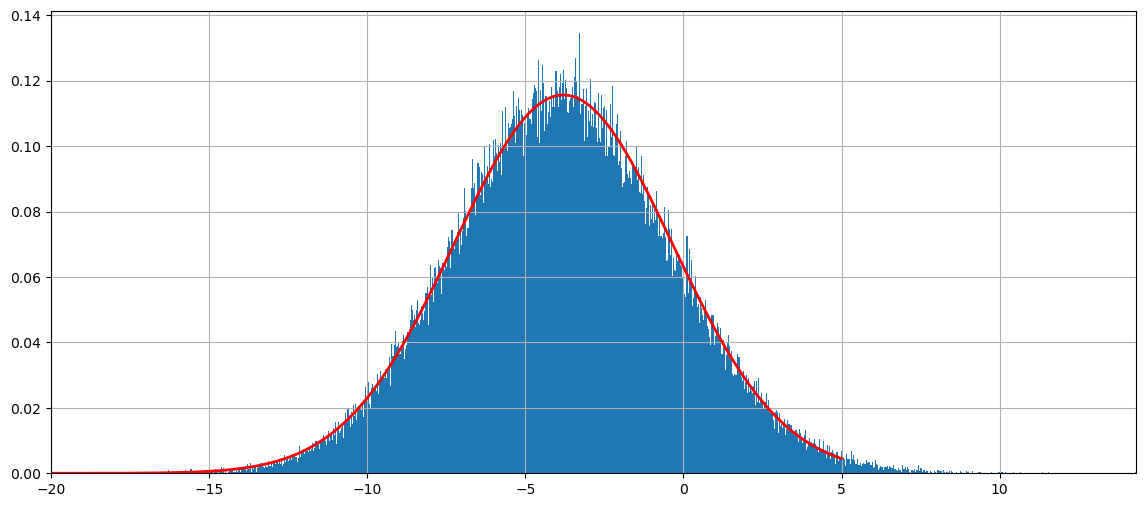

In [33]:
plt.figure(figsize=(14,6))
plt.plot(x, y_pdf , color = "red" , lw = 2)
plt.hist(bootstrap , bins = 1000 , density=True)

plt.autoscale(enable=True , axis ="x" , tight=True)
plt.grid()
plt.show()

# Well Done!

---------------------------------------------------------------------------------------------------------------------